<a href="https://colab.research.google.com/github/diyasonly19/northstar_database/blob/main/Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# ── IMPORT ALL REQUIRED LIBRARIES ─────
import pandas as pd           # data manipulation and analysis
import numpy as np            # numerical computing
import matplotlib.pyplot as plt  # data visualisation
import seaborn as sns         # advanced visualisation
import warnings
warnings.filterwarnings('ignore')

# Set consistent chart style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
# Loading datasets directly from GitHub repository

import pandas as pd

BASE_URL = "https://raw.githubusercontent.com/diyasonly19/northstar_database/main/northstar_dataset/"

orders = pd.read_csv(BASE_URL + "orders.csv")
deliveries = pd.read_csv(BASE_URL + "deliveries.csv")
customers = pd.read_csv(BASE_URL + "customers.csv")
drivers = pd.read_csv(BASE_URL + "drivers.csv")
vehicles = pd.read_csv(BASE_URL + "vehicles.csv")
complaints = pd.read_csv(BASE_URL + "complaints.csv")
incidents = pd.read_csv(BASE_URL + "incidents.csv")
hubs = pd.read_csv(BASE_URL + "hubs.csv")

print("All datasets loaded successfully!")

for name, df in {
    "orders": orders,
    "deliveries": deliveries,
    "customers": customers,
    "drivers": drivers,
    "vehicles": vehicles,
    "complaints": complaints,
    "incidents": incidents,
    "hubs": hubs
}.items():
    print(f"{name}: {df.shape[0]} rows × {df.shape[1]} cols")

All datasets loaded successfully!
orders: 1250 rows × 11 cols
deliveries: 950 rows × 13 cols
customers: 650 rows × 9 cols
drivers: 170 rows × 8 cols
vehicles: 120 rows × 8 cols
complaints: 320 rows × 10 cols
incidents: 280 rows × 7 cols
hubs: 8 rows × 5 cols


In [8]:
# STANDARDISE ZONE VALUES
# Convert all zone labels to uppercase and remove spaces
# Ensures consistent grouping in all subsequent analysis

orders['pickup_zone']     = orders['pickup_zone'].str.upper().str.strip()
orders['dropoff_zone']    = orders['dropoff_zone'].str.upper().str.strip()
drivers['base_zone']      = drivers['base_zone'].str.upper().str.strip()
vehicles['assigned_zone'] = vehicles['assigned_zone'].str.upper().str.strip()
customers['home_zone']    = customers['home_zone'].str.upper().str.strip()

print("Zone values standardised!")
print("Unique pickup zones:", sorted(orders['pickup_zone'].unique()))

Zone values standardised!
Unique pickup zones: ['AIRPORT', 'CENTRAL', 'CTR', 'EAST', 'NORTH', 'RIVERSIDE', 'SOUTH', 'WEST']


In [9]:
# COMBINING DATASETS
# pd.merge() joins two tables on a shared column
# Python's equivalent of SQL JOIN

# Merge 1: Orders + Deliveries (main working dataset)
df = pd.merge(orders, deliveries, on='order_id', how='inner')
print(f"Orders + Deliveries merged: {df.shape[0]} rows × {df.shape[1]} columns")

# Merge 2: Add driver details
df = pd.merge(df, drivers, on='driver_id', how='left')
print(f"After adding Drivers:        {df.shape[0]} rows × {df.shape[1]} columns")

# Merge 3: Add vehicle details
df = pd.merge(df, vehicles, on='vehicle_id', how='left')
print(f"After adding Vehicles:       {df.shape[0]} rows × {df.shape[1]} columns")

# Merge 4: Add hub details
df = pd.merge(df, hubs, on='hub_id', how='left')
print(f"After adding Hubs:           {df.shape[0]} rows × {df.shape[1]} columns")

print(f"\nFinal combined dataset columns:\n{list(df.columns)}")

Orders + Deliveries merged: 950 rows × 23 columns
After adding Drivers:        950 rows × 30 columns
After adding Vehicles:       950 rows × 37 columns
After adding Hubs:           950 rows × 41 columns

Final combined dataset columns:
['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag', 'delivery_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost', 'base_zone', 'employment_type', 'years_experience', 'training_score', 'driver_rating', 'shift_preference', 'active_flag', 'vehicle_type', 'assigned_zone', 'commission_date', 'battery_health_pct', 'odometer_km', 'maintenance_status', 'telematics_version', 'hub_name', 'zone', 'hub_type', 'capacity_score']


In [10]:
# EXPLORATORY DATA ANALYSIS
print("=== COMBINED DATASET OVERVIEW ===")
print(df.info())

=== COMBINED DATASET OVERVIEW ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 41 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       950 non-null    object 
 1   customer_id                    950 non-null    object 
 2   service_type                   950 non-null    object 
 3   order_created_at               950 non-null    object 
 4   promised_window_hours          950 non-null    int64  
 5   pickup_zone                    950 non-null    object 
 6   dropoff_zone                   950 non-null    object 
 7   priority_level                 950 non-null    object 
 8   order_value                    950 non-null    float64
 9   booking_channel                929 non-null    object 
 10  special_handling_flag          950 non-null    int64  
 11  delivery_id                    950 non-null    object 
 12  driver_id       

In [11]:
print("=== MISSING VALUES IN COMBINED DATASET ===")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== MISSING VALUES IN COMBINED DATASET ===
training_score                   40
battery_health_pct               25
booking_channel                  21
delivery_completed_at            19
customer_rating_post_delivery    14
dtype: int64

Total missing values: 119


In [12]:
print("=== DESCRIPTIVE STATISTICS — NUMERIC COLUMNS ===")
numeric_cols = ['order_value', 'route_distance_km',
                'fuel_or_charge_cost',
                'customer_rating_post_delivery',
                'manual_route_override_count',
                'promised_window_hours']
print(df[numeric_cols].describe().round(2))

=== DESCRIPTIVE STATISTICS — NUMERIC COLUMNS ===
       order_value  route_distance_km  fuel_or_charge_cost  \
count       950.00             950.00               950.00   
mean         91.86              13.91                12.84   
std          62.00               7.48                 4.34   
min           2.04               1.20                 2.50   
25%          48.61               9.14                 9.93   
50%          77.17              12.84                12.64   
75%         122.82              16.84                15.70   
max         510.06              41.94                29.43   

       customer_rating_post_delivery  manual_route_override_count  \
count                         936.00                       950.00   
mean                            3.86                         0.97   
std                             0.89                         1.09   
min                             1.00                         0.00   
25%                             3.36           

In [13]:
print("=== KEY CATEGORICAL VALUES ===")
print("Delivery statuses: ", df['delivery_status'].unique())
print("Service types:     ", df['service_type'].unique())
print("Priority levels:   ", df['priority_level'].unique())
print("Vehicle types:     ", df['vehicle_type'].unique())
print("Maintenance status:", df['maintenance_status'].unique())

=== KEY CATEGORICAL VALUES ===
Delivery statuses:  ['OnTime' 'Delayed' 'Failed']
Service types:      ['Passenger' 'Parcel' 'Retail' 'Business' 'Medical']
Priority levels:    ['Medium' 'High' 'Low' 'Critical']
Vehicle types:      ['Hybrid' 'CargoVan' 'Diesel' 'EV']
Maintenance status: ['InRepair' 'Active' 'Scheduled']


In [14]:
# --DATA CLEANING --

# Display the number of missing values before cleaning
# This helps identify which columns need fixing
print("=== BEFORE CLEANING ===")

# Count missing customer ratings
print(f"Missing customer ratings:    "
      f"{df['customer_rating_post_delivery'].isnull().sum()}")

# Count missing delivery completion timestamps
print(f"Missing completion times:    "
      f"{df['delivery_completed_at'].isnull().sum()}")

# Count missing compensation amounts in complaints data
print(f"Missing compensation values: "
      f"{complaints['compensation_amount'].isnull().sum()}")

# Count missing preferred communication channels
print(f"Missing preferred channel:   "
      f"{customers['preferred_channel'].isnull().sum()}")


# ─ DATA CLEANING STEPS ─

# Fix 1:
# Replace missing customer ratings with the median rating
# Median is used because it is less affected by extreme values
median_rating = df['customer_rating_post_delivery'].median()

df['customer_rating_post_delivery'] = \
    df['customer_rating_post_delivery'].fillna(median_rating)


# Fix 2:
# Replace missing compensation amounts with 0
# Missing values likely mean no compensation was given
complaints['compensation_amount'] = \
    complaints['compensation_amount'].fillna(0)


# Fix 3:
# Replace missing preferred channels with "Unknown"
# This keeps the records instead of deleting customer rows
customers['preferred_channel'] = \
    customers['preferred_channel'].fillna('Unknown')


# Fix 4:
# Remove rows where delivery completion time is missing
# These records cannot be used for delivery performance analysis
df = df.dropna(subset=['delivery_completed_at'])


#  DISPLAY RESULTS AFTER CLEANING

# Show missing values after all cleaning steps
print("\n=== AFTER CLEANING ===")

# Check remaining missing customer ratings
print(f"Missing customer ratings:    "
      f"{df['customer_rating_post_delivery'].isnull().sum()}")

# Check remaining missing completion times
print(f"Missing completion times:    "
      f"{df['delivery_completed_at'].isnull().sum()}")

# Check remaining missing compensation values
print(f"Missing compensation values: "
      f"{complaints['compensation_amount'].isnull().sum()}")

# Check remaining missing preferred channels
print(f"Missing preferred channel:   "
      f"{customers['preferred_channel'].isnull().sum()}")


# Display final dataset size after cleaning
print(f"\nClean dataset size: {df.shape[0]} rows")

=== BEFORE CLEANING ===
Missing customer ratings:    14
Missing completion times:    19
Missing compensation values: 16
Missing preferred channel:   13

=== AFTER CLEANING ===
Missing customer ratings:    0
Missing completion times:    0
Missing compensation values: 0
Missing preferred channel:   0

Clean dataset size: 931 rows


In [15]:
# ----------FEATURE ENGINEERING ------------------
# Feature engineering creates new variables from existing data
# to improve analysis and generate deeper business insights


# 1. Net profit per delivery
# Calculate profit by subtracting fuel/charge cost
# from the total order value
df['net_profit'] = df['order_value'] - df['fuel_or_charge_cost']


# 2. On-time binary flag
# Convert delivery status into a binary variable:
# 1 = OnTime delivery
# 0 = Not OnTime
# Useful for statistical analysis and machine learning
df['is_ontime'] = (df['delivery_status'] == 'OnTime').astype(int)


# 3. High value order classification using NumPy where()
# Calculate average order value across all deliveries
mean_val = df['order_value'].mean()

# Orders above the mean are labelled "High"
# Orders equal/below the mean are labelled "Low"
df['order_tier'] = np.where(df['order_value'] > mean_val, 'High', 'Low')


# 4. Delivery duration in hours
# Convert columns into datetime format first
df['dispatch_time'] = pd.to_datetime(df['dispatch_time'])
df['delivery_completed_at'] = pd.to_datetime(df['delivery_completed_at'])

# Calculate total delivery duration in hours
# total_seconds() converts time difference into seconds
# Dividing by 3600 converts seconds into hours
df['duration_hrs'] = (
    df['delivery_completed_at'] - df['dispatch_time']
).dt.total_seconds() / 3600


# 5. Cost efficiency calculation
# Measure delivery cost per kilometre travelled
# Rounded to 2 decimal places for readability
df['cost_per_km'] = np.round(
    df['fuel_or_charge_cost'] / df['route_distance_km'], 2
)


# 6. Delivery performance classification
# Use multiple conditions to categorise performance quality
conditions = [

    # Condition 1: Delivery completed on time
    df['delivery_status'] == 'OnTime',

    # Condition 2: Delivery delayed
    df['delivery_status'] == 'Delayed',

    # Condition 3: Delivery failed
    df['delivery_status'] == 'Failed'
]

# Labels assigned to each condition
choices = ['Good', 'Warning', 'Critical']

# Create final performance category column
df['performance_flag'] = np.select(
    conditions,
    choices,
    default='Unknown'
)


# ── DISPLAY RESULTS

# Show confirmation message
print("=== NEW COLUMNS CREATED ===")

# Display average order value used as threshold
print(f"Mean order value threshold: £{mean_val:.2f}\n")


# Display sample of newly created columns
print(df[['order_id', 'order_value', 'net_profit',
          'is_ontime', 'order_tier', 'duration_hrs',
          'cost_per_km', 'performance_flag']]
      .head(8)
      .to_string())

=== NEW COLUMNS CREATED ===
Mean order value threshold: £92.31

  order_id  order_value  net_profit  is_ontime order_tier  duration_hrs  cost_per_km performance_flag
0   O00001       126.65      110.83          1       High      2.398937         0.59             Good
1   O00003        33.50       20.34          0        Low      8.861012         1.01          Warning
2   O00004        10.04       -3.37          1        Low     -1.100000         1.30             Good
3   O00005       125.58      112.05          1       High     11.700013         0.85             Good
4   O00007        76.12       66.36          0        Low      8.921543         1.08          Warning
5   O00008        35.06       22.19          1        Low      0.415726         0.91             Good
6   O00009        78.93       67.52          1        Low      9.748426         0.95             Good
7   O00010        34.55       20.80          1        Low      2.996207         0.88             Good


In [16]:
# NUMPY STATISTICS
# NumPy provides precise statistical measures

print("=== ORDER VALUE — FULL STATISTICAL PROFILE ===")
vals = df['order_value'].values
print(f"Count:           {len(vals)}")
print(f"Mean:            £{np.mean(vals):.2f}")
print(f"Median:          £{np.median(vals):.2f}")
print(f"Std Deviation:   £{np.std(vals):.2f}")
print(f"Variance:         {np.var(vals):.2f}")
print(f"Minimum:         £{np.min(vals):.2f}")
print(f"Maximum:         £{np.max(vals):.2f}")
print(f"Range:           £{np.ptp(vals):.2f}")
print(f"25th Percentile: £{np.percentile(vals, 25):.2f}")
print(f"75th Percentile: £{np.percentile(vals, 75):.2f}")
print(f"IQR:             £{np.percentile(vals, 75) - np.percentile(vals, 25):.2f}")
print(f"Skewness:         {pd.Series(vals).skew():.3f}")

print("\n=== NET PROFIT BY SERVICE TYPE ===")
for stype in sorted(df['service_type'].unique()):
    subset = df[df['service_type'] == stype]['net_profit'].values
    print(f"\n{stype}:")
    print(f"  Mean:   £{np.mean(subset):.2f} | "
          f"Median: £{np.median(subset):.2f} | "
          f"Std: £{np.std(subset):.2f} | "
          f"Min: £{np.min(subset):.2f} | "
          f"Max: £{np.max(subset):.2f}")

print("\n=== DELIVERY DURATION STATISTICS ===")
dur = df['duration_hrs'].dropna().values
print(f"Mean:          {np.mean(dur):.2f} hours")
print(f"Median:        {np.median(dur):.2f} hours")
print(f"Std Deviation: {np.std(dur):.2f} hours")
print(f"90th Pctile:   {np.percentile(dur, 90):.2f} hours")
print(f"Max:           {np.max(dur):.2f} hours")

=== ORDER VALUE — FULL STATISTICAL PROFILE ===
Count:           931
Mean:            £92.31
Median:          £77.58
Std Deviation:   £62.04
Variance:         3849.36
Minimum:         £2.04
Maximum:         £510.06
Range:           £508.02
25th Percentile: £49.00
75th Percentile: £123.23
IQR:             £74.23
Skewness:         1.360

=== NET PROFIT BY SERVICE TYPE ===

Business:
  Mean:   £84.84 | Median: £70.78 | Std: £64.58 | Min: £-9.42 | Max: £304.70

Medical:
  Mean:   £75.18 | Median: £61.31 | Std: £60.14 | Min: £-8.33 | Max: £277.57

Parcel:
  Mean:   £77.30 | Median: £59.70 | Std: £63.68 | Min: £-5.48 | Max: £489.52

Passenger:
  Mean:   £84.80 | Median: £71.86 | Std: £63.07 | Min: £-6.76 | Max: £309.20

Retail:
  Mean:   £74.36 | Median: £60.45 | Std: £58.76 | Min: £-9.15 | Max: £285.68

=== DELIVERY DURATION STATISTICS ===
Mean:          9.55 hours
Median:        7.07 hours
Std Deviation: 8.64 hours
90th Pctile:   22.21 hours
Max:           43.46 hours


In [17]:
# GROUPBY ANALYSIS
# groupby() is used to summarise performance metrics for each pickup zone

zone_perf = df.groupby('pickup_zone').agg(

    total_orders      = ('order_id', 'count'),
    # total number of orders in each zone

    total_revenue     = ('order_value', 'sum'),
    # total revenue generated

    avg_order_value   = ('order_value', 'mean'),
    # average value per order

    avg_net_profit    = ('net_profit', 'mean'),
    # average profit earned

    ontime_rate_pct   = ('is_ontime', 'mean'),
    # average of binary values gives on-time rate

    avg_rating        = ('customer_rating_post_delivery', 'mean'),
    # average customer rating

    avg_duration_hrs  = ('duration_hrs', 'mean'),
    # average delivery duration

    avg_cost_per_km   = ('cost_per_km', 'mean')
    # average operational cost efficiency

).round(2)


# FAILURE RATE CALCULATION
# counts failed deliveries for each pickup zone

failed = df[df['delivery_status'] == 'Failed'] \
           .groupby('pickup_zone')['order_id'].count()

zone_perf['failure_rate_pct'] = (
    failed / zone_perf['total_orders'] * 100
).round(1)


# Convert on-time rate into percentage format

zone_perf['ontime_rate_pct'] = (
    zone_perf['ontime_rate_pct'] * 100
).round(1)


# Sort zones by highest failure rate first

zone_perf = zone_perf.sort_values(
    'failure_rate_pct',
    ascending=False
)

print(zone_perf.to_string())

             total_orders  total_revenue  avg_order_value  avg_net_profit  ontime_rate_pct  avg_rating  avg_duration_hrs  avg_cost_per_km  failure_rate_pct
pickup_zone                                                                                                                                                
CENTRAL               106        9111.01            85.95           73.73             57.0        3.66             10.40             1.24              19.8
CTR                    62        5729.29            92.41           80.09             45.0        3.43             10.74             1.48              17.7
NORTH                 133       11909.84            89.55           77.48             68.0        3.89              9.19             1.34              16.5
RIVERSIDE             117       10614.55            90.72           78.37             63.0        3.86             10.04             1.43              15.4
WEST                  111        9991.17            90.01       

In [18]:
# CORRELATION ANALYSIS
# Correlation measures how strongly two variables move together
# Range: -1 (opposite) to +1 (same direction), 0 = no relationship

numeric_cols = [
    'order_value', 'route_distance_km', 'fuel_or_charge_cost',
    'customer_rating_post_delivery', 'manual_route_override_count',
    'net_profit', 'duration_hrs', 'cost_per_km',
    'years_experience', 'driver_rating', 'training_score'
]

corr_matrix = df[numeric_cols].corr().round(2)

print("=== CORRELATION MATRIX ===")
print(corr_matrix.to_string())

print("\n=== KEY CORRELATION FINDINGS ===")
print(f"Order value vs net profit:        "
      f"{corr_matrix.loc['order_value','net_profit']}")
print(f"Distance vs fuel cost:            "
      f"{corr_matrix.loc['route_distance_km','fuel_or_charge_cost']}")
print(f"Overrides vs customer rating:     "
      f"{corr_matrix.loc['manual_route_override_count','customer_rating_post_delivery']}")
print(f"Driver rating vs customer rating: "
      f"{corr_matrix.loc['driver_rating','customer_rating_post_delivery']}")
print(f"Experience vs driver rating:      "
      f"{corr_matrix.loc['years_experience','driver_rating']}")
print(f"Training score vs driver rating:  "
      f"{corr_matrix.loc['training_score','driver_rating']}")

=== CORRELATION MATRIX ===
                               order_value  route_distance_km  fuel_or_charge_cost  customer_rating_post_delivery  manual_route_override_count  net_profit  duration_hrs  cost_per_km  years_experience  driver_rating  training_score
order_value                           1.00               0.06                -0.02                          -0.00                         0.02        1.00          0.00        -0.05              0.02          -0.03            0.04
route_distance_km                     0.06               1.00                 0.52                           0.03                         0.21        0.02          0.02        -0.51             -0.03           0.01           -0.07
fuel_or_charge_cost                  -0.02               0.52                 1.00                          -0.06                         0.10       -0.09          0.05         0.01             -0.06          -0.01           -0.02
customer_rating_post_delivery        -0.00       

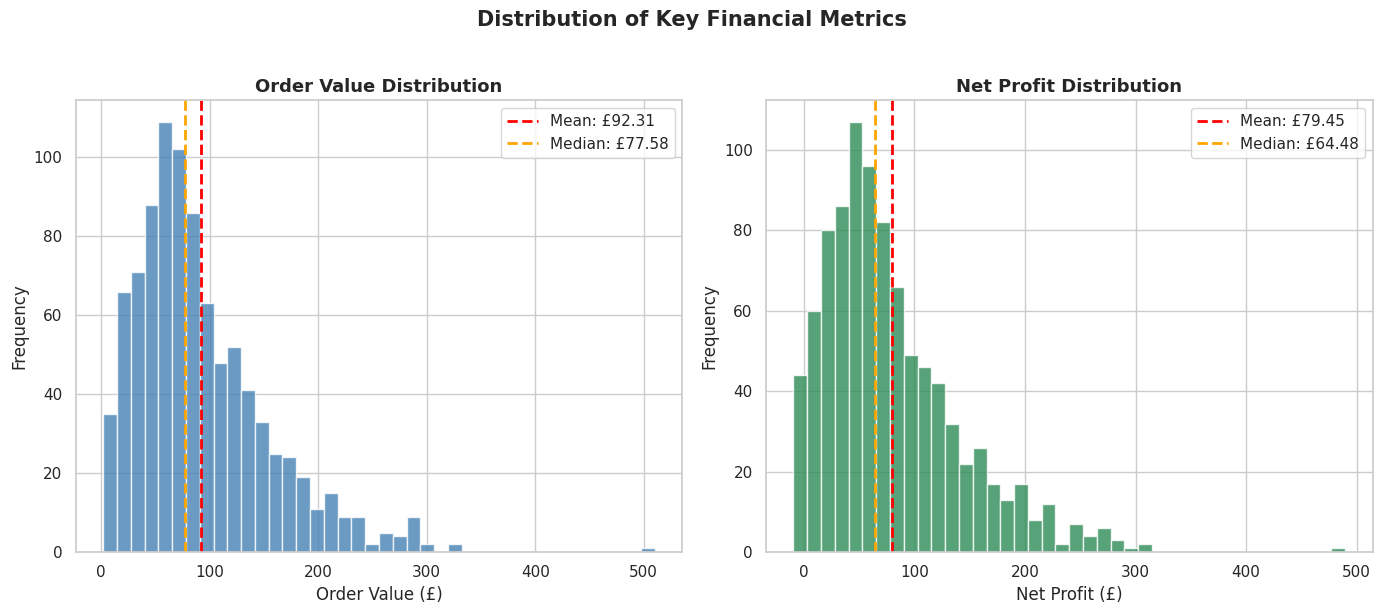

In [19]:
# HISTOGRAM
# Histograms show how a numeric variable is distributed
# Best for understanding the shape, spread and skew of data

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Order value distribution
axes[0].hist(df['order_value'], bins=40,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['order_value'].mean(),
                color='red', linestyle='--', linewidth=2,
                label=f"Mean: £{df['order_value'].mean():.2f}")
axes[0].axvline(df['order_value'].median(),
                color='orange', linestyle='--', linewidth=2,
                label=f"Median: £{df['order_value'].median():.2f}")
axes[0].set_title('Order Value Distribution',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Order Value (£)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Right: Net profit distribution
axes[1].hist(df['net_profit'], bins=40,
             color='seagreen', edgecolor='white', alpha=0.8)
axes[1].axvline(df['net_profit'].mean(),
                color='red', linestyle='--', linewidth=2,
                label=f"Mean: £{df['net_profit'].mean():.2f}")
axes[1].axvline(df['net_profit'].median(),
                color='orange', linestyle='--', linewidth=2,
                label=f"Median: £{df['net_profit'].median():.2f}")
axes[1].set_title('Net Profit Distribution',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Net Profit (£)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Distribution of Key Financial Metrics',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

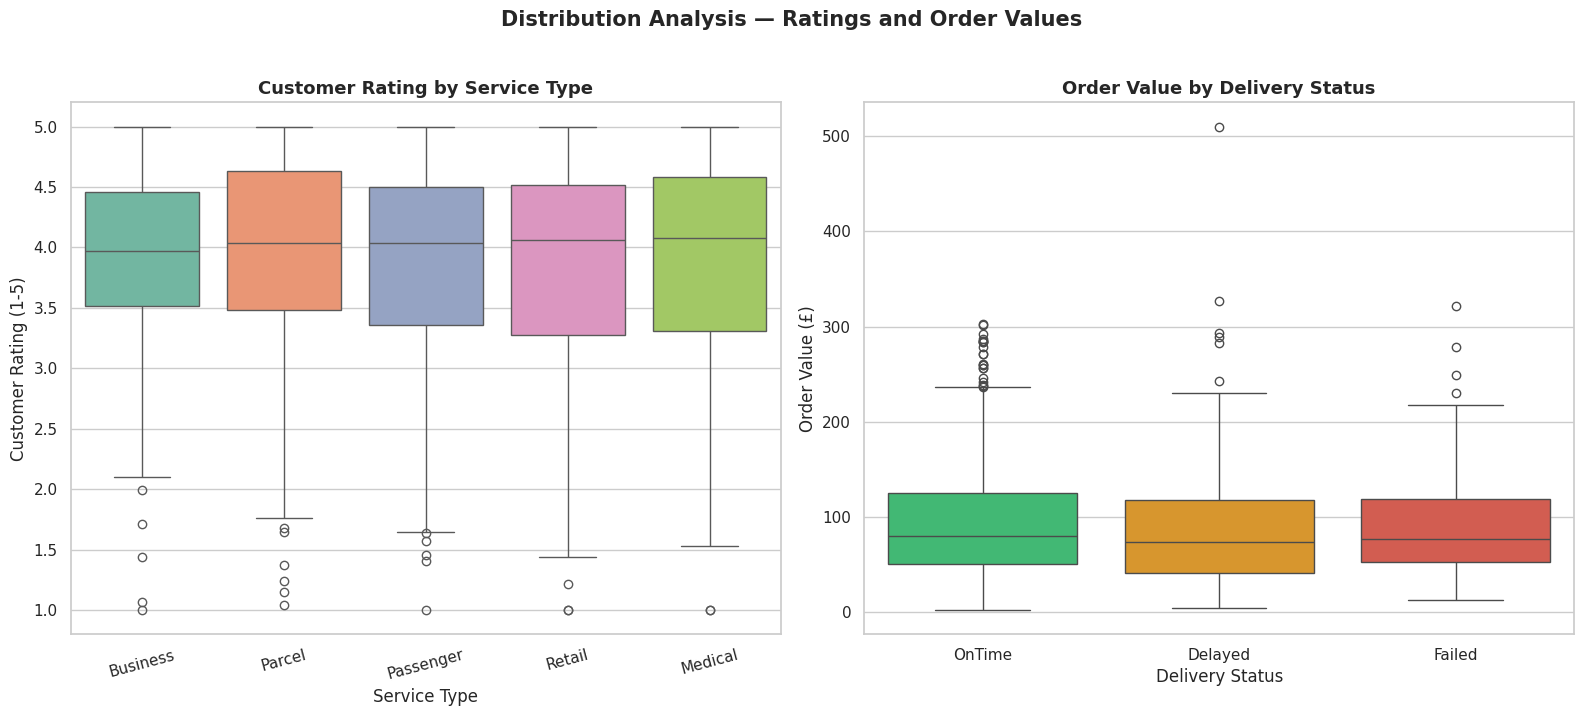

In [20]:
# BOX PLOT
# Box plots show median, spread and outliers simultaneously
# Better than bar charts for understanding data distribution

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Customer rating by service type
service_order = df.groupby('service_type')[
    'customer_rating_post_delivery'].median().sort_values().index

sns.boxplot(
    data=df,
    x='service_type',
    y='customer_rating_post_delivery',
    order=service_order,
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Customer Rating by Service Type',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Service Type')
axes[0].set_ylabel('Customer Rating (1-5)')
axes[0].tick_params(axis='x', rotation=15)

# Right: Order value by delivery status
status_order = ['OnTime', 'Delayed', 'Failed']
sns.boxplot(
    data=df,
    x='delivery_status',
    y='order_value',
    order=status_order,
    palette={'OnTime': '#2ecc71',
             'Delayed': '#f39c12',
             'Failed': '#e74c3c'},
    ax=axes[1]
)
axes[1].set_title('Order Value by Delivery Status',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Delivery Status')
axes[1].set_ylabel('Order Value (£)')

plt.suptitle('Distribution Analysis — Ratings and Order Values',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

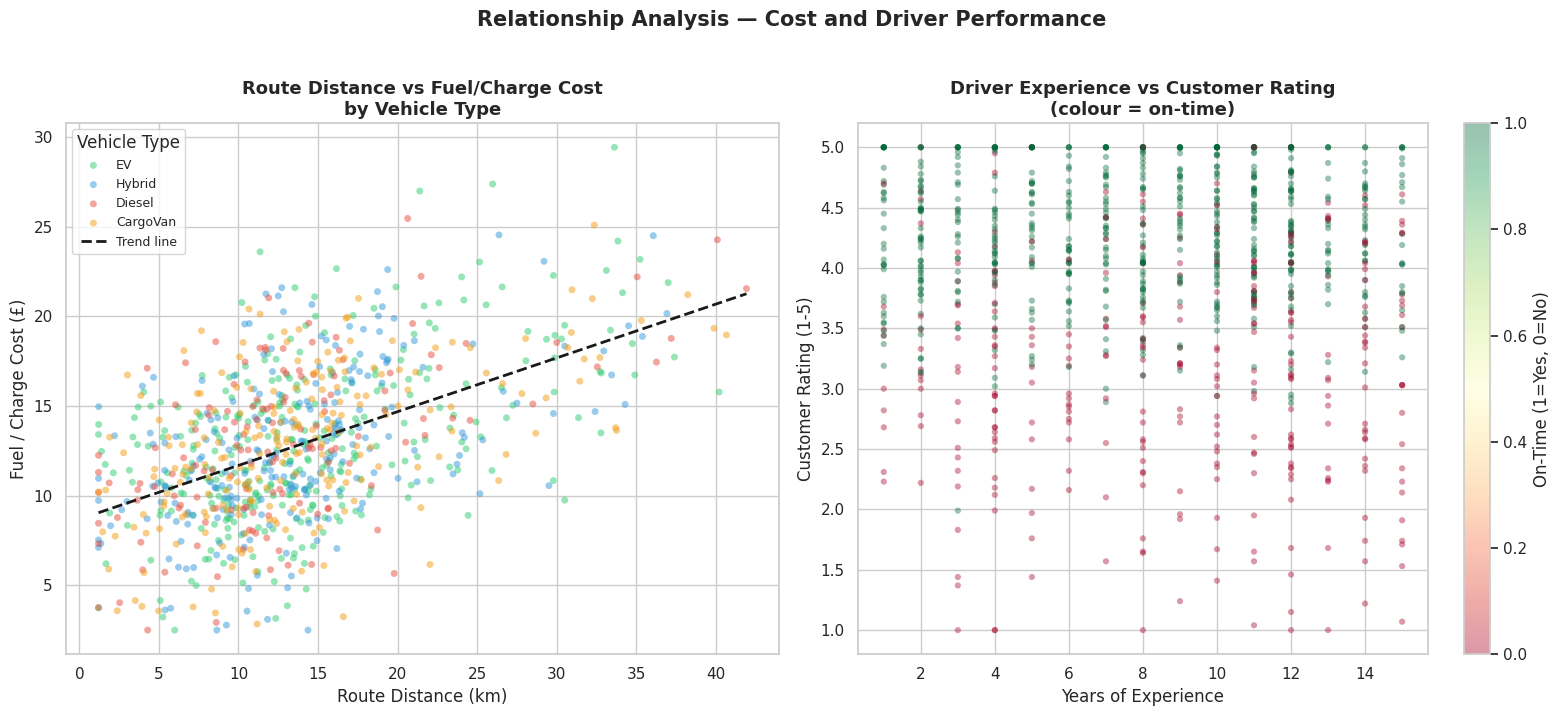

In [21]:
# SCATTER PLOT
# Scatter plots show the relationship between two numeric variables
# Each point = one delivery

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Distance vs fuel cost coloured by vehicle type
vehicle_colors = {
    'EV'      : '#2ecc71',
    'Hybrid'  : '#3498db',
    'Diesel'  : '#e74c3c',
    'CargoVan': '#f39c12'
}

for vtype, color in vehicle_colors.items():
    subset = df[df['vehicle_type'] == vtype]
    axes[0].scatter(
        subset['route_distance_km'],
        subset['fuel_or_charge_cost'],
        label=vtype, color=color,
        alpha=0.5, s=25, edgecolors='none'
    )

# Add trend line using NumPy polyfit
z = np.polyfit(df['route_distance_km'].dropna(),
               df['fuel_or_charge_cost'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df['route_distance_km'].min(),
                     df['route_distance_km'].max(), 100)
axes[0].plot(x_line, p(x_line), 'k--',
             linewidth=2, label='Trend line')
axes[0].set_title('Route Distance vs Fuel/Charge Cost\nby Vehicle Type',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Route Distance (km)')
axes[0].set_ylabel('Fuel / Charge Cost (£)')
axes[0].legend(title='Vehicle Type', fontsize=9)

# Right: Driver experience vs customer rating
scatter = axes[1].scatter(
    df['years_experience'],
    df['customer_rating_post_delivery'],
    c=df['is_ontime'],
    cmap='RdYlGn',
    alpha=0.4, s=20, edgecolors='none'
)
plt.colorbar(scatter, ax=axes[1],
             label='On-Time (1=Yes, 0=No)')
axes[1].set_title('Driver Experience vs Customer Rating\n(colour = on-time)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Years of Experience')
axes[1].set_ylabel('Customer Rating (1-5)')

plt.suptitle('Relationship Analysis — Cost and Driver Performance',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()